# 10 - analysis of the cultivation data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/02_all_signal_peptides/biochemical_results_synthetic_signalpeptides.csv', index_col=False)

In [3]:
df.head()


,SP_ID,n_relative_length,n_kd_hydrophobicity,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7
0,SP_997,1.0,-1.3,0.200809,14.0,1.993333,-0.147963,4.0,-0.760000,-0.533796
1,SP_944,1.0,-1.0,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772
2,SP_948,1.0,-1.0,0.196884,12.0,2.623077,-0.590986,3.0,0.500000,-0.823772
3,SP_993,1.0,-1.0,0.196884,14.0,3.166667,-0.505667,5.0,0.083333,-0.590986
4,SP_204,1.0,-1.3,0.200809,15.0,2.156250,-0.590986,6.0,-0.171429,-0.823772


# UMAP calculation

In [4]:
import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import hdbscan
import seaborn as sns
import matplotlib.colors as mcolors


# Prepare the DataFrame by dropping non-numeric columns
data_for_umap = df.drop(columns=['SP_ID', ])

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_umap)

# Apply UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=12345)
umap_results = umap_model.fit_transform(scaled_data)

# Create a DataFrame from UMAP results
umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])

# Concatenate the UMAP results with the original DataFrame
df_with_umap = pd.concat([df.reset_index(drop=True), umap_df], axis=1)

# Output for consistency - already did this so will comment out
#output_csv_path = '../data/02_all_signal_peptides/biochbiochemical_results_synthetic_signalpeptides_with_UMAP.csv'
#df_with_umap.to_csv(output_csv_path, index=False)

umap_df = pd.read_csv('../data/02_all_signal_peptides/biochbiochemical_results_synthetic_signalpeptides_with_UMAP.csv')
umap_results = umap_df[['UMAP1', 'UMAP2']].to_numpy()



/Users/lucaslevassor/opt/anaconda3/envs/py_3_10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lucaslevassor/opt/anaconda3/envs/py_3_10/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [5]:
umap_df.rename(columns={'SP_ID': 'SecretoGen_ID' }, inplace=True)
umap_df

,SecretoGen_ID,n_relative_length,n_kd_hydrophobicity,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7,UMAP1,UMAP2
0,SP_997,1.0,-1.30,0.200809,14.0,1.993333,-0.147963,4.0,-0.760000,-0.533796,12.152558,11.500423
1,SP_944,1.0,-1.00,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772,12.508060,12.180136
2,SP_948,1.0,-1.00,0.196884,12.0,2.623077,-0.590986,3.0,0.500000,-0.823772,12.163406,12.584727
3,SP_993,1.0,-1.00,0.196884,14.0,3.166667,-0.505667,5.0,0.083333,-0.590986,12.531946,12.251487
4,SP_204,1.0,-1.30,0.200809,15.0,2.156250,-0.590986,6.0,-0.171429,-0.823772,12.067452,11.895136
...,...,...,...,...,...,...,...,...,...,...,...,...
994,SP_656,1.0,3.05,-0.799151,11.0,1.916667,-0.557223,5.0,0.466667,-0.857574,0.676114,4.669903
995,SP_696,1.0,3.05,-0.799151,11.0,2.066667,-0.557223,5.0,0.533333,-0.857574,0.714400,4.665617
996,SP_757,1.0,3.05,-0.799151,11.0,2.066667,-0.557223,8.0,0.688889,-0.857574,0.560213,4.759068
997,SP_253,1.0,3.05,-0.799151,11.0,1.916667,-0.557223,5.0,0.533333,-0.857574,0.726163,4.657144


## UMAP with K-means

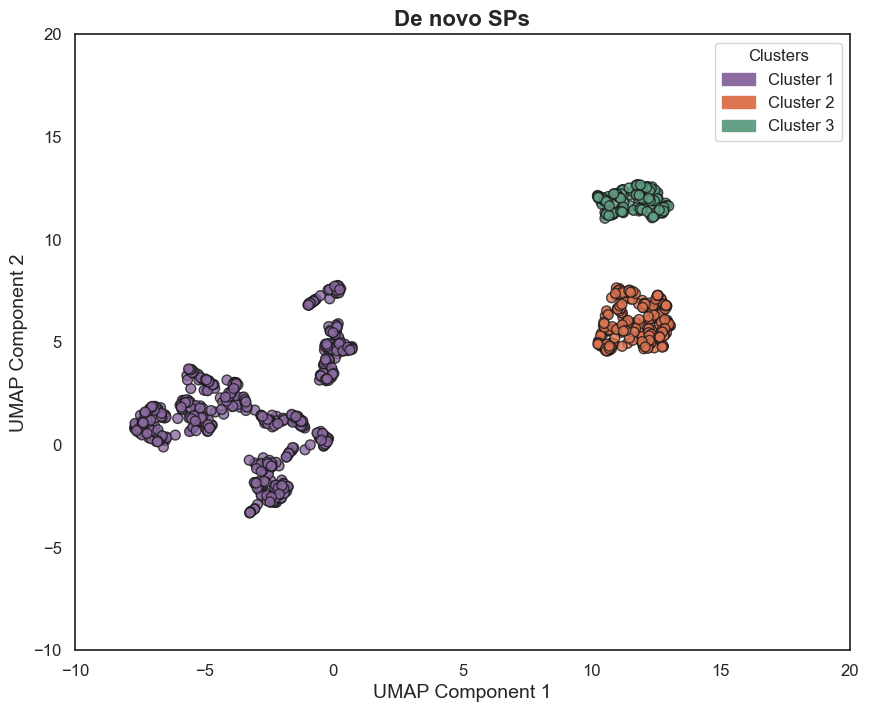

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import umap.umap_ as umap
import numpy as np
import matplotlib.patches as mpatches

NUMBER_OF_CLUSTERS = 3

# Define custom colors from the image
custom_palette = [ '#8C6AA2',  '#DD7552', '#63A086']

# Apply K-means clustering
kmeans = KMeans(n_clusters=NUMBER_OF_CLUSTERS, random_state=1234)
kmeans_clusters = kmeans.fit_predict(umap_results)

# Ensure the number of colors matches the number of clusters
palette = custom_palette[:NUMBER_OF_CLUSTERS]

# Set Seaborn style
sns.set(style='white', context='notebook')

# Convert cluster labels to colors
cluster_colors = [palette[label] for label in kmeans_clusters]

# Visualize the results with clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_results[:, 0], umap_results[:, 1], c=cluster_colors, s=50, alpha=0.8, edgecolor='k')

# Create a legend with color patches in the top-right corner
legend_patches = [mpatches.Patch(color=palette[i], label=f'Cluster {i+1}') for i in range(NUMBER_OF_CLUSTERS)]
plt.legend(handles=legend_patches, title="Clusters", loc="upper right", fontsize=12)

# Enhancing plot aesthetics
plt.title('De novo SPs', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Component 1', fontsize=14)
plt.ylabel('UMAP Component 2', fontsize=14)

# Set the axes limits as requested
plt.xlim(-10, 20)
plt.ylim(-10, 20)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the figure
plt.savefig('../data/plots/UMAP_kmeans_clustering_syn_sps.png', dpi=300, bbox_inches='tight')

plt.show()



# Merging with the experimental data

In [7]:
df2 = pd.read_excel('../data/16_experimental_data_from_cultivation_studies/SP FL data 2.0.xlsx', index_col=False)
df2.rename(columns={'Compared to glaA': 'Relative increase' }, inplace=True)
df2['SP_ID'] = df2['SP'].str.replace(r'^(SP)(\d+)$', r'\1_\2', regex=True)
df2

,SP Plate Form.,SP,Avg Norm.,STD Norm.,Perplexity Score,Length,Relative increase,P-value glaA 2T,P-value ORY7 1 2T,SP_ID
0,SP_A2_10,SP94,5.414871e+07,5.171315e+06,1.860671,24,5.181963,3.270513e-09,2.205555e-09,SP_94
1,SP_A2_6,SP90,4.445493e+07,2.282416e+06,1.935643,19,4.254280,1.132295e-13,1.351941e-11,SP_90
2,SP_A2_4,SP88,3.992128e+07,7.391652e+06,2.015560,22,3.820416,2.577961e-06,4.437781e-07,SP_88
3,SP_A2_7,SP91,3.473437e+07,1.639991e+06,1.925576,19,3.324035,3.631285e-15,5.911061e-12,SP_91
4,SP_A2_1,SP85,3.031828e+07,2.064168e+06,2.045515,19,2.901421,8.343771e-12,1.438364e-10,SP_85
...,...,...,...,...,...,...,...,...,...,...
115,SP_A2,SP2,1.712379e+06,8.195118e+04,7.421489,23,0.163872,2.082126e-08,7.649190e-03,SP_2
116,SP_C10,SP34,1.697390e+06,1.409994e+05,3.497278,21,0.162438,1.659705e-08,1.818511e-02,SP_34
117,SP_A2_2,SP86,1.596881e+06,9.470174e+04,2.045189,23,0.152819,1.807468e-08,1.354492e-01,SP_86
118,ORY7 1,ORY7 1,1.478958e+06,1.854867e+05,0.000000,0,0.141534,NaN,1.000000e+00,ORY7 1


In [8]:
selected_rows1 = pd.read_excel('../data/09_primers/full_dataframe_of_sampled_SPs_2024_09_03.xlsx')
selected_rows2 = pd.read_excel('../data/09_primers/full_dataframe_of_sampled_SPs_2024_14_11.xlsx')

concat_selected_rows = pd.concat([selected_rows1, selected_rows2])
concat_selected_rows.rename(columns={'sp_name': 'SP_ID' }, inplace=True)

In [9]:
# Merge DataFrames based on 'SP_ID'
merged_df = pd.merge(concat_selected_rows, df2, on='SP_ID', how='right')  # inner join
merged_df2 = pd.merge(merged_df, umap_df, on='SecretoGen_ID', how='left')  # inner join

merged_df2

,Unnamed: 0,SecretoGen_ID,Sequence,Perplexity,Length_x,codon_optimized_sequences,SP_ID,fwd_primers(5-3),rev_primers(5-3),SP Plate Form.,...,n_kd_hydrophobicity,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7,UMAP1,UMAP2
0,9.0,SP_423,MVLIKPLLTTALLASASLLSPATA,1.860671,24.0,ATGGTCTTGATCAAGCCTCTTCTGACTACAGCGCTGCTCGCATCCG...,SP_94,CAGCGCTGCTCGCATCCGCTTCTCTACTCAGCCCCGCCACCGCCGC...,TGAGTAGAGAAGCGGATGCGAGCAGCGCTGTAGTCAGAAGAGGCTT...,SP_A2_10,...,3.050000,-0.799151,16.0,1.647059,0.438812,4.0,0.100000,-0.823772,-7.065228,1.795361
1,5.0,SP_45,MVAIKSLLVSGLLTTASLA,1.935643,19.0,ATGGTGGCTATCAAGTCCCTCCTGGTCAGCGGCTTGCTAACCACTG...,SP_90,AGTCCCTCCTGGTCAGCGGCTTGCTAACCACTGCATCTCTTGCCGC...,TGGTTAGCAAGCCGCTGACCAGGAGGGACTTGATAGCCACCATGGT...,SP_A2_6,...,2.633333,-0.799151,12.0,1.415385,0.438812,5.0,0.833333,-0.823772,-2.457203,-2.774916
2,3.0,SP_182,MVHIKSLATAVLATSFLSPALA,2.015560,22.0,ATGGTCCATATCAAGTCCCTGGCAACTGCGGTGTTGGCCACCTCTT...,SP_88,CAACTGCGGTGTTGGCCACCTCTTTCCTCAGCCCTGCCCTTGCTGC...,TGAGGAAAGAGGTGGCCAACACCGCAGTTGCCAGGGACTTGATATG...,SP_A2_4,...,0.966667,-0.775725,13.0,1.528571,0.438812,4.0,1.000000,-0.823772,-2.393826,-2.543008
3,6.0,SP_108,MVAIKSLLLSGLLATQAWA,1.925576,19.0,ATGGTCGCCATCAAGTCCCTACTGCTTAGCGGCCTCTTGGCTACCC...,SP_91,AGTCCCTACTGCTTAGCGGCCTCTTGGCTACCCAGGCGTGGGCAGC...,TAGCCAAGAGGCCGCTAAGCAGTAGGGACTTGATGGCGACCATGGT...,SP_A2_7,...,3.050000,-0.799151,11.0,1.766667,0.490368,4.0,-0.300000,-0.857574,-6.808649,0.150623
4,0.0,SP_462,MVAIKSLLLTALLATQAWA,2.045515,19.0,ATGGTCGCGATCAAGTCCCTCCTACTGACTGCATTGCTTGCTACCC...,SP_85,AGTCCCTCCTACTGACTGCATTGCTTGCTACCCAGGCCTGGGCCGC...,TAGCAAGCAATGCAGTCAGTAGGAGGGACTTGATCGCGACCATGGT...,SP_A2_1,...,3.050000,-0.799151,11.0,1.958333,0.490368,4.0,-0.300000,-0.857574,-6.793770,0.199028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.0,SP_944,MKFTLIILIIVILTIIFSPGALA,7.421489,23.0,ATGAAGTTTACCTTGATCATACTCATCATTGTCATTCTGACTATTA...,SP_2,TCATTGTCATTCTGACTATTATCTTCTCCCCTGGCGCCCTTGCTGC...,GGGAGAAGATAATAGTCAGAATGACAATGATGAGTATGATCAAGGT...,SP_A2,...,-1.000000,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772,12.508060,12.180136
116,33.0,SP_982,MILSNTILVATLAALSGLAHA,3.497278,21.0,ATGATCCTAAGCAACACTATTCTGGTCGCAACCTTGGCGGCCCTCT...,SP_34,TTCTGGTCGCAACCTTGGCGGCCCTCTCCGGCCTTGCCCATGCTGC...,CGGAGAGGGCCGCCAAGGTTGCGACCAGAATAGTGTTGCTTAGGAT...,SP_C10,...,3.200000,-0.799151,15.0,1.637500,-0.557223,2.0,0.133333,-0.482241,-0.286864,4.198725
117,1.0,SP_201,MVQIKSFAVLATAISLLSTPAAA,2.045189,23.0,ATGGTCCAGATTAAGAGCTTCGCGGTGCTCGCCACTGCCATCTCTC...,SP_86,TGCTCGCCACTGCCATCTCTCTTCTGTCCACCCCTGCAGCTGCTGC...,TGGACAGAAGAGAGATGGCAGTGGCGAGCACCGCGAAGCTCTTAAT...,SP_A2_2,...,0.866667,-0.799151,14.0,1.720000,0.438812,4.0,0.620000,-0.857574,-2.089424,-2.391147
118,NaN,NaN,NaN,NaN,NaN,NaN,ORY7 1,NaN,NaN,ORY7 1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There is some mistake here. lets try again: 

In [10]:



# Dendogram with best signal peptides
#synthetic_sps_secretogen = pd.read_csv('../data/15_SecretoGen/Best_signal_peptides_for_A_oryzae_RFP_his_tag_sorted.csv')
##synthetic_sps_secretogen.rename(columns={'Perplexity': 'Perplexity Score' }, inplace=True)
#synthetic_sps_secretogen.rename(columns={'SP_ID': 'SP_ID_Secretogen' }, inplace=True)

#synthetic_sps_secretogen['SP'] = synthetic_sps_secretogen['SP_ID'].str.replace('_', '')

#merged_df3 = pd.merge(df2, synthetic_sps_secretogen, on='Perplexity Score', how='inner')  # inner join

#merged_df4 = pd.merge(merged_df3, umap_df, on='Perplexity Score', how='inner')  # inner join


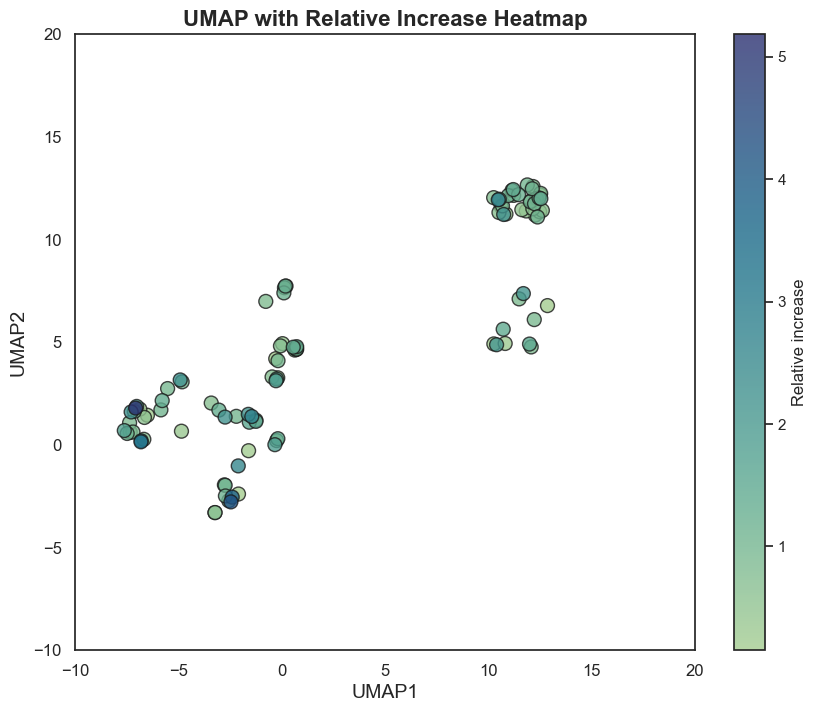

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

merged_df2 = merged_df2.sort_values(by='Relative increase', ascending=True)
# Set Seaborn style for a cleaner look
sns.set(style='white', context='notebook')

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    merged_df2['UMAP1'],
    merged_df2['UMAP2'],
    c=merged_df2['Relative increase'],
    cmap='crest',  # Choose a colormap; 'viridis' is often a good default
    s=100,
    alpha=0.8,
    edgecolor='k'
)

# Add a color bar to indicate the mapping of colors to 'Relative increase' values
cbar = plt.colorbar(scatter)
cbar.set_label('Relative increase', fontsize=12)

# Enhance the plot aesthetics
plt.title('UMAP with Relative Increase Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('UMAP1', fontsize=20)
plt.ylabel('UMAP2', fontsize=20)

# Set the axes limits if needed (adjust as per your data)
plt.xlim(-10, 20)
plt.ylim(-10, 20)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the figure (adjust the path and filename as needed)
plt.savefig('UMAP_relative_increase_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()


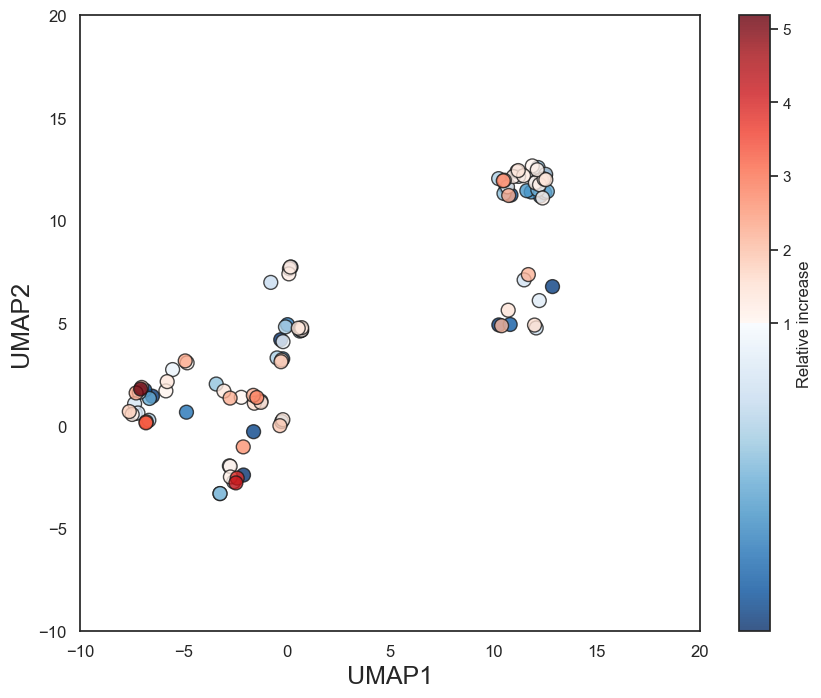

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

# Assuming merged_df2 is already defined and sorted as in your code

sns.set(style='white', context='notebook')
plt.figure(figsize=(10, 8))

# Define two colormaps: one for values below 1 and one for above 1.
# You can adjust these choices as needed.
cmap_low = plt.cm.Blues_r   # For values below 1
cmap_high = plt.cm.Reds      # For values above 1

# Number of colors to sample from each half of the new colormap
ncolors = 256
ncolors_half = ncolors // 2

# Sample colors from each colormap
colors_low = cmap_low(np.linspace(0, 1, ncolors_half))
colors_high = cmap_high(np.linspace(0, 1, ncolors_half))

# Combine the two sets of colors into a single colormap
new_colors = np.vstack((colors_low, colors_high))
custom_cmap = mcolors.LinearSegmentedColormap.from_list('CustomMap', new_colors)

# Create a normalization that centers on the threshold value of 1.
# This scales the colors so that 1 is the midpoint between the two colormap halves.
vmin = merged_df2['Relative increase'].min()
vmax = merged_df2['Relative increase'].max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

# Create the scatter plot using the custom colormap and normalization
scatter = plt.scatter(
    merged_df2['UMAP1'],
    merged_df2['UMAP2'],
    c=merged_df2['Relative increase'],
    cmap=custom_cmap,
    norm=norm,
    s=100,
    alpha=0.8,
    edgecolor='k'
)

# Add a colorbar with appropriate labeling
cbar = plt.colorbar(scatter)
cbar.set_label('Relative increase', fontsize=12)

# Enhance the plot aesthetics
plt.title('', fontsize=16, fontweight='bold')
plt.xlabel('UMAP1', fontsize=18)
plt.ylabel('UMAP2', fontsize=18)
plt.xlim(-10, 20)
plt.ylim(-10, 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('UMAP_relative_increase_heatmap1.png', dpi=300, bbox_inches='tight')
plt.show()


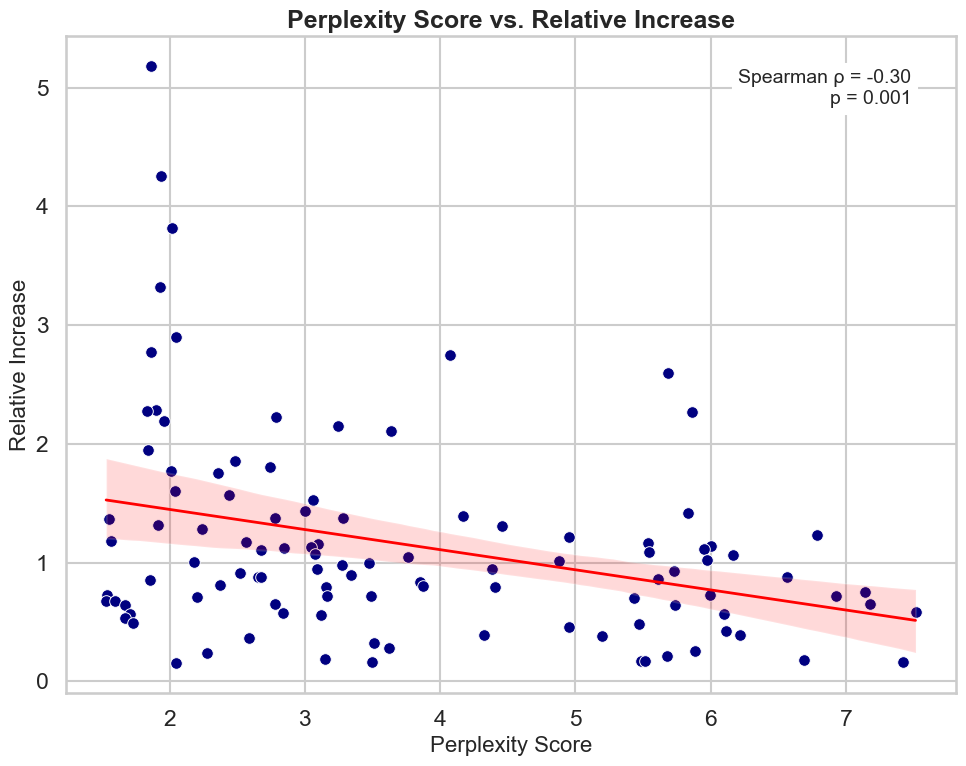

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import pandas as pd


# remove natural and ory7
df3 = df2[df2['Perplexity Score'] != 0]


# Compute the Spearman correlation coefficient and p-value
rho, pval = spearmanr(df3['Perplexity Score'], df3['Relative increase'])

# Set a publication style (you can customize as needed)
sns.set(style='whitegrid', context='talk')

plt.figure(figsize=(10, 8))

# Create the scatterplot
sns.scatterplot(data=df3, x='Perplexity Score', y='Relative increase', s=70, color='navy', edgecolor='w')

# Optionally, add a regression line (if you think a trendline is appropriate)
sns.regplot(data=df3, x='Perplexity Score', y='Relative increase', scatter=False, color='red', 
            line_kws={'linewidth': 2})


# Annotate the plot with the Spearman correlation results in the top right corner
plt.annotate(f"Spearman ρ = {rho:.2f}\np = {pval:.3f}",
             xy=(0.95, 0.95), xycoords='axes fraction',
             fontsize=14, backgroundcolor='white', verticalalignment='top', horizontalalignment='right')

# Customize the plot labels and title
plt.title("Perplexity Score vs. Relative Increase", fontsize=18, fontweight='bold')
plt.xlabel("Perplexity Score", fontsize=16)
plt.ylabel("Relative Increase", fontsize=16)

plt.tight_layout()
plt.savefig("Perplexity_vs_RelativeIncrease.png", dpi=300, bbox_inches='tight')
plt.show()

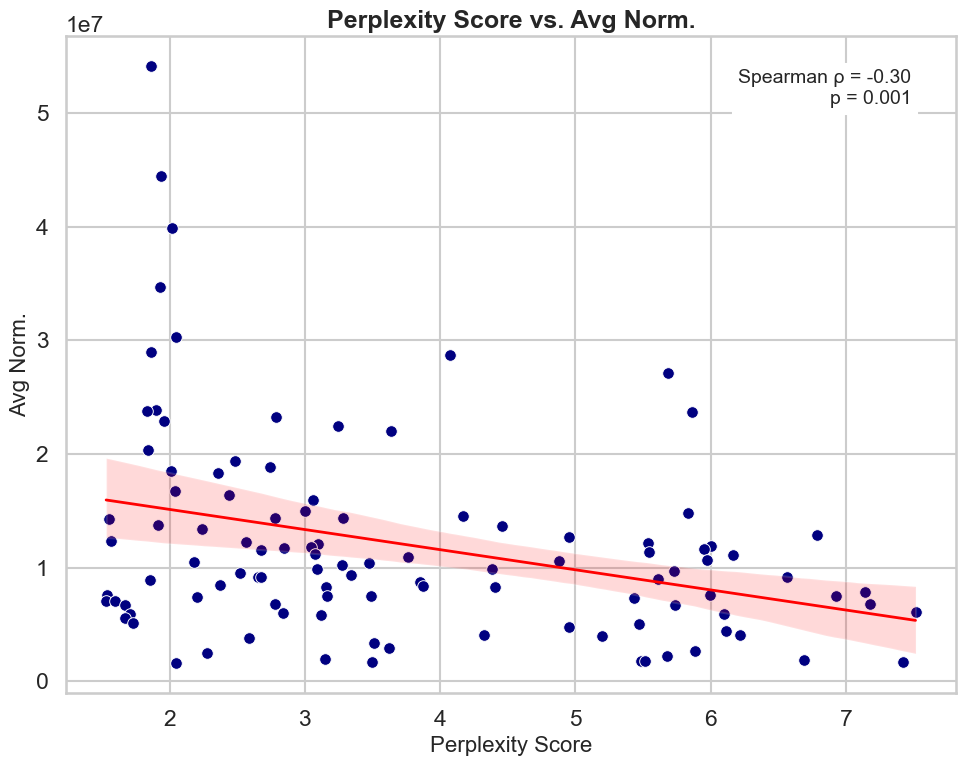

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import pandas as pd

# remove natural and ory7
#df3 = df2[df2['Perplexity Score'] != 0]

# Compute the Spearman correlation coefficient and p-value for 'Avg Norm.'
rho, pval = spearmanr(df3['Perplexity Score'], df3['Avg Norm.'])

# Set a publication style (you can customize as needed)
sns.set(style='whitegrid', context='talk')

plt.figure(figsize=(10, 8))

# Create the scatterplot with 'Avg Norm.' on the y-axis
sns.scatterplot(data=df3, x='Perplexity Score', y='Avg Norm.', s=70, color='navy', edgecolor='w')

# Optionally, add a regression line (if you think a trendline is appropriate)
sns.regplot(data=df3, x='Perplexity Score', y='Avg Norm.', scatter=False, color='red', 
            line_kws={'linewidth': 2})

# Annotate the plot with the Spearman correlation results in the top right corner
plt.annotate(f"Spearman ρ = {rho:.2f}\np = {pval:.3f}",
             xy=(0.95, 0.95), xycoords='axes fraction',
             fontsize=14, backgroundcolor='white', verticalalignment='top', horizontalalignment='right')

# Customize the plot labels and title
plt.title("Perplexity Score vs. Avg Norm.", fontsize=18, fontweight='bold')
plt.xlabel("Perplexity Score", fontsize=16)
plt.ylabel("Avg Norm.", fontsize=16)

plt.tight_layout()
plt.savefig("Perplexity_vs_AvgNorm.png", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# Dendogram with best signal peptides
#synthetic_sps_secretogen = pd.read_csv('../data/15_SecretoGen/Best_signal_peptides_for_A_oryzae_RFP_his_tag_sorted.csv')
#synthetic_sps_secretogen.rename(columns={'Perplexity': 'Perplexity Score' }, inplace=True)
#synthetic_sps_secretogen.rename(columns={'SP_ID': 'SP_ID_Secretogen' }, inplace=True)

#synthetic_sps_secretogen['SP'] = synthetic_sps_secretogen['SP_ID'].str.replace('_', '')

#merged_df3 = pd.merge(df2, synthetic_sps_secretogen, on='Perplexity Score', how='inner')  # inner join

#merged_df3

# mucsle alignemnt

In [15]:
merged_df3  = merged_df2.dropna()
merged_df3.sort_values(by='Relative increase', ascending= True)

,Unnamed: 0,SecretoGen_ID,Sequence,Perplexity,Length_x,codon_optimized_sequences,SP_ID,fwd_primers(5-3),rev_primers(5-3),SP Plate Form.,...,n_kd_hydrophobicity,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7,UMAP1,UMAP2
117,1.0,SP_201,MVQIKSFAVLATAISLLSTPAAA,2.045189,23.0,ATGGTCCAGATTAAGAGCTTCGCGGTGCTCGCCACTGCCATCTCTC...,SP_86,TGCTCGCCACTGCCATCTCTCTTCTGTCCACCCCTGCAGCTGCTGC...,TGGACAGAAGAGAGATGGCAGTGGCGAGCACCGCGAAGCTCTTAAT...,SP_A2_2,...,0.866667,-0.799151,14.0,1.720000,0.438812,4.0,0.620000,-0.857574,-2.089424,-2.391147
116,33.0,SP_982,MILSNTILVATLAALSGLAHA,3.497278,21.0,ATGATCCTAAGCAACACTATTCTGGTCGCAACCTTGGCGGCCCTCT...,SP_34,TTCTGGTCGCAACCTTGGCGGCCCTCTCCGGCCTTGCCCATGCTGC...,CGGAGAGGGCCGCCAAGGTTGCGACCAGAATAGTGTTGCTTAGGAT...,SP_C10,...,3.200000,-0.799151,15.0,1.637500,-0.557223,2.0,0.133333,-0.482241,-0.286864,4.198725
115,1.0,SP_944,MKFTLIILIIVILTIIFSPGALA,7.421489,23.0,ATGAAGTTTACCTTGATCATACTCATCATTGTCATTCTGACTATTA...,SP_2,TCATTGTCATTCTGACTATTATCTTCTCCCCTGGCGCCCTTGCTGC...,GGGAGAAGATAATAGTCAGAATGACAATGATGAGTATGATCAAGGT...,SP_A2,...,-1.000000,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772,12.508060,12.180136
114,26.0,SP_668,MKLSNFVTTLVLSTPFASA,5.515908,19.0,ATGAAGCTGAGCAACTTCGTCACAACTCTTGTGCTCTCCACCCCTT...,SP_27,ACTTCGTCACAACTCTTGTGCTCTCCACCCCTTTTGCTTCTGCCGC...,GGGTGGAGAGCACAAGAGTTGTGACGAAGTTGCTCAGCTTCATGGT...,SP_C3,...,-1.000000,0.196884,13.0,1.185714,-0.557223,2.0,0.933333,-0.505667,10.619610,11.610014
113,27.0,SP_33,MLLRYLLTVVLAVGLVLS,5.482622,18.0,ATGCTACTGCGCTACCTGCTCACCGTAGTCCTTGCCGTTGGCCTCG...,SP_28,GCTACCTGCTCACCGTAGTCCTTGCCGTTGGCCTCGTGTTGTCCGC...,CAACGGCAAGGACTACGGTGAGCAGGTAGCGCAGTAGCATGGTGAA...,SP_C4,...,2.850000,-0.799151,14.0,2.300000,0.438772,3.0,-0.150000,-0.823772,-6.497145,1.445499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.0,SP_462,MVAIKSLLLTALLATQAWA,2.045515,19.0,ATGGTCGCGATCAAGTCCCTCCTACTGACTGCATTGCTTGCTACCC...,SP_85,AGTCCCTCCTACTGACTGCATTGCTTGCTACCCAGGCCTGGGCCGC...,TAGCAAGCAATGCAGTCAGTAGGAGGGACTTGATCGCGACCATGGT...,SP_A2_1,...,3.050000,-0.799151,11.0,1.958333,0.490368,4.0,-0.300000,-0.857574,-6.793770,0.199028
3,6.0,SP_108,MVAIKSLLLSGLLATQAWA,1.925576,19.0,ATGGTCGCCATCAAGTCCCTACTGCTTAGCGGCCTCTTGGCTACCC...,SP_91,AGTCCCTACTGCTTAGCGGCCTCTTGGCTACCCAGGCGTGGGCAGC...,TAGCCAAGAGGCCGCTAAGCAGTAGGGACTTGATGGCGACCATGGT...,SP_A2_7,...,3.050000,-0.799151,11.0,1.766667,0.490368,4.0,-0.300000,-0.857574,-6.808649,0.150623
2,3.0,SP_182,MVHIKSLATAVLATSFLSPALA,2.015560,22.0,ATGGTCCATATCAAGTCCCTGGCAACTGCGGTGTTGGCCACCTCTT...,SP_88,CAACTGCGGTGTTGGCCACCTCTTTCCTCAGCCCTGCCCTTGCTGC...,TGAGGAAAGAGGTGGCCAACACCGCAGTTGCCAGGGACTTGATATG...,SP_A2_4,...,0.966667,-0.775725,13.0,1.528571,0.438812,4.0,1.000000,-0.823772,-2.393826,-2.543008
1,5.0,SP_45,MVAIKSLLVSGLLTTASLA,1.935643,19.0,ATGGTGGCTATCAAGTCCCTCCTGGTCAGCGGCTTGCTAACCACTG...,SP_90,AGTCCCTCCTGGTCAGCGGCTTGCTAACCACTGCATCTCTTGCCGC...,TGGTTAGCAAGCCGCTGACCAGGAGGGACTTGATAGCCACCATGGT...,SP_A2_6,...,2.633333,-0.799151,12.0,1.415385,0.438812,5.0,0.833333,-0.823772,-2.457203,-2.774916


In [16]:
from Bio import SeqIO
from Bio.Seq import Seq

from Bio.SeqRecord import SeqRecord


# Create SeqRecord objects for each sequence.
records = [
    SeqRecord(Seq(row["Sequence"]), id=str(row["SP_ID"]), description="")
    for idx, row in merged_df3.iterrows()
]


# Write the records to a FASTA file.
with open("sequences_1.fasta", "w") as output_handle:
    SeqIO.write(records, output_handle, "fasta")
    
print("FASTA file 'sequences.fasta' created successfully.")

FASTA file 'sequences.fasta' created successfully.


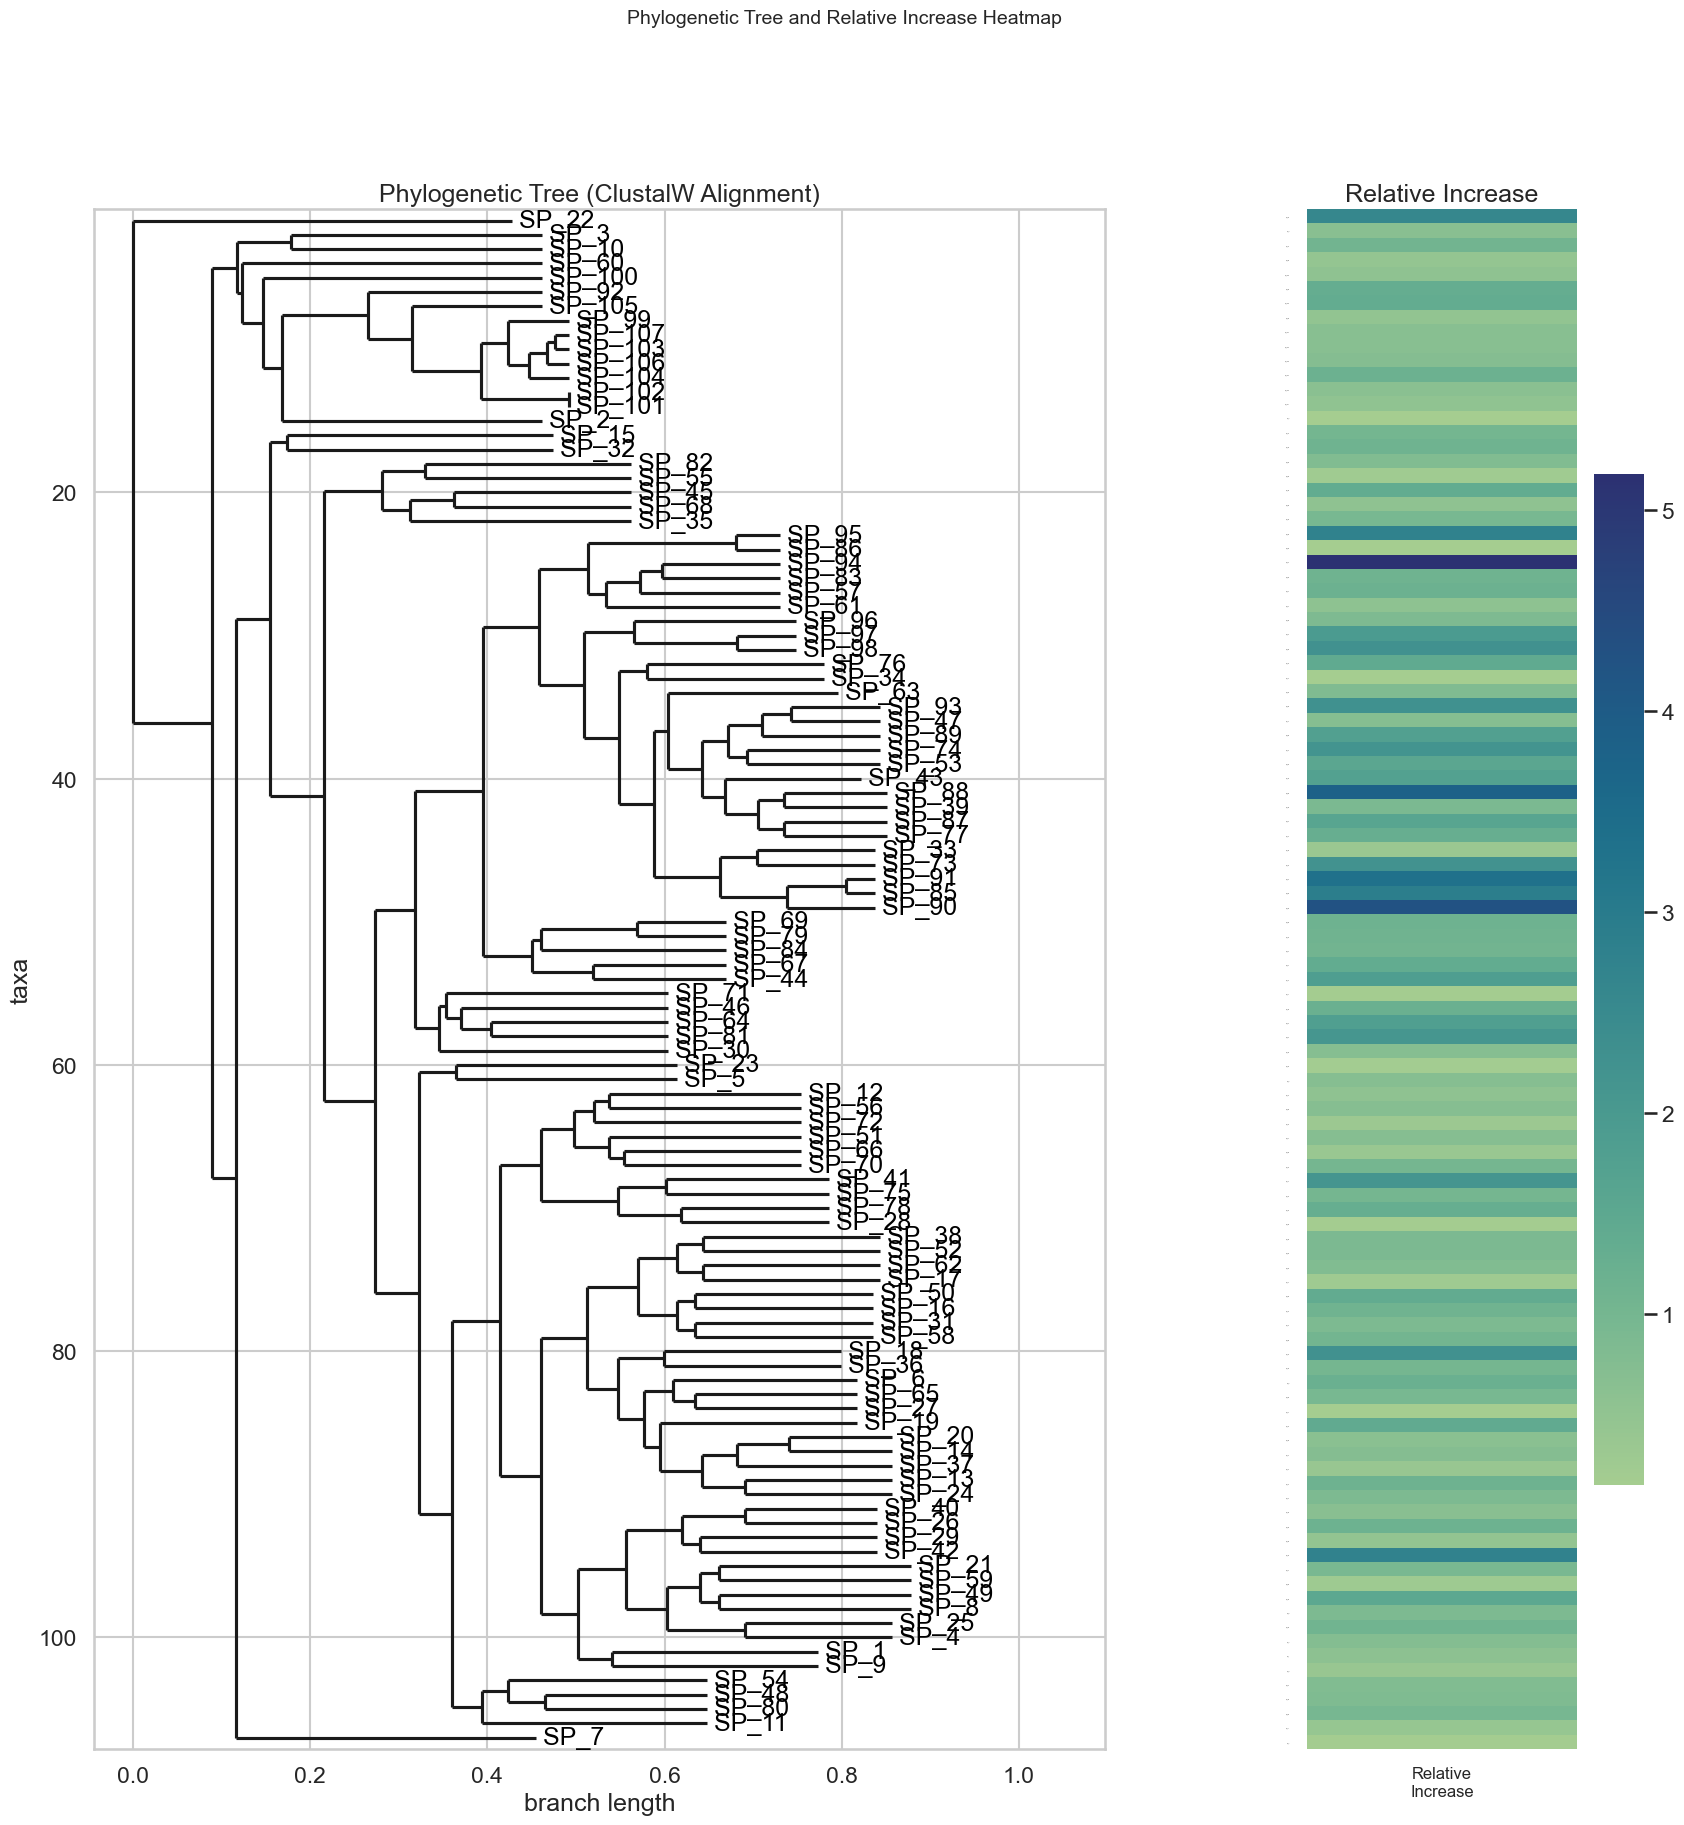

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.gridspec as gridspec

# --- Step 1: Load the ClustalW Alignment ---
# Replace "alignment.aln" with the path to your ClustalW file.
alignment = AlignIO.read("alignment1.aln", "clustal")

# --- Step 2: Build a Phylogenetic Tree ---
calculator = DistanceCalculator("identity")
dm = calculator.get_distance(alignment)
constructor = DistanceTreeConstructor()
tree = constructor.upgma(dm)

# Remove internal node labels for a cleaner tree display.
for clade in tree.get_nonterminals():
    clade.name = None

# --- Step 3: Prepare Relative Increase Data ---
# Replace with your actual data from merged_df3.
df_1 = pd.DataFrame({
    'id': merged_df3['SP_ID'].to_list(),
    'sequence': merged_df3['Sequence'].to_list(),
    'Relative increase': merged_df3['Relative increase'].to_list()
})

# --- Step 4: Reorder Data According to the Tree ---
terminals = tree.get_terminals()
terminal_ids = [t.name for t in terminals]

# Reorder the DataFrame to match the terminal order.
df_ordered = df_1.set_index('id').loc[terminal_ids].reset_index()
heatmap_data = np.array(df_ordered['Relative increase']).reshape(-1, 1)

# --- Step 5: Plot the Tree and the Heatmap Side by Side with GridSpec ---
fig = plt.figure(figsize=(20, 20))

# Define a 1-row, 2-column grid, giving the left column more width than the right.
gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)

# Subplot for the phylogenetic tree (left, wider).
ax_tree = fig.add_subplot(gs[0, 0])
Phylo.draw(tree, do_show=False, axes=ax_tree)
ax_tree.set_title("Phylogenetic Tree (ClustalW Alignment)")

# Custum palette on crest

# Subplot for the heatmap (right, narrower).
ax_heatmap = fig.add_subplot(gs[0, 1])
sns.heatmap(
    heatmap_data,
    cmap='crest',
    cbar=True,
    yticklabels=df_ordered['id'],
    annot=False,
    ax=ax_heatmap, 
    #vmin=1 #
)
ax_heatmap.set_xticklabels(['Relative\nIncrease'], rotation=0, fontsize=12)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0, fontsize=0)
ax_heatmap.set_title("Relative Increase")

plt.suptitle("Phylogenetic Tree and Relative Increase Heatmap", fontsize=14)
plt.show()


# Figuring out closest SP relatives to the natural SPs

In [18]:
merged_df2

,Unnamed: 0,SecretoGen_ID,Sequence,Perplexity,Length_x,codon_optimized_sequences,SP_ID,fwd_primers(5-3),rev_primers(5-3),SP Plate Form.,...,n_kd_hydrophobicity,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7,UMAP1,UMAP2
119,NaN,NaN,NaN,NaN,NaN,NaN,ORY7 2,NaN,NaN,ORY7 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,NaN,NaN,NaN,NaN,NaN,NaN,ORY7 1,NaN,NaN,ORY7 1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,1.0,SP_201,MVQIKSFAVLATAISLLSTPAAA,2.045189,23.0,ATGGTCCAGATTAAGAGCTTCGCGGTGCTCGCCACTGCCATCTCTC...,SP_86,TGCTCGCCACTGCCATCTCTCTTCTGTCCACCCCTGCAGCTGCTGC...,TGGACAGAAGAGAGATGGCAGTGGCGAGCACCGCGAAGCTCTTAAT...,SP_A2_2,...,0.866667,-0.799151,14.0,1.720000,0.438812,4.0,0.620000,-0.857574,-2.089424,-2.391147
116,33.0,SP_982,MILSNTILVATLAALSGLAHA,3.497278,21.0,ATGATCCTAAGCAACACTATTCTGGTCGCAACCTTGGCGGCCCTCT...,SP_34,TTCTGGTCGCAACCTTGGCGGCCCTCTCCGGCCTTGCCCATGCTGC...,CGGAGAGGGCCGCCAAGGTTGCGACCAGAATAGTGTTGCTTAGGAT...,SP_C10,...,3.200000,-0.799151,15.0,1.637500,-0.557223,2.0,0.133333,-0.482241,-0.286864,4.198725
115,1.0,SP_944,MKFTLIILIIVILTIIFSPGALA,7.421489,23.0,ATGAAGTTTACCTTGATCATACTCATCATTGTCATTCTGACTATTA...,SP_2,TCATTGTCATTCTGACTATTATCTTCTCCCCTGGCGCCCTTGCTGC...,GGGAGAAGATAATAGTCAGAATGACAATGATGAGTATGATCAAGGT...,SP_A2,...,-1.000000,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772,12.508060,12.180136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.0,SP_462,MVAIKSLLLTALLATQAWA,2.045515,19.0,ATGGTCGCGATCAAGTCCCTCCTACTGACTGCATTGCTTGCTACCC...,SP_85,AGTCCCTCCTACTGACTGCATTGCTTGCTACCCAGGCCTGGGCCGC...,TAGCAAGCAATGCAGTCAGTAGGAGGGACTTGATCGCGACCATGGT...,SP_A2_1,...,3.050000,-0.799151,11.0,1.958333,0.490368,4.0,-0.300000,-0.857574,-6.793770,0.199028
3,6.0,SP_108,MVAIKSLLLSGLLATQAWA,1.925576,19.0,ATGGTCGCCATCAAGTCCCTACTGCTTAGCGGCCTCTTGGCTACCC...,SP_91,AGTCCCTACTGCTTAGCGGCCTCTTGGCTACCCAGGCGTGGGCAGC...,TAGCCAAGAGGCCGCTAAGCAGTAGGGACTTGATGGCGACCATGGT...,SP_A2_7,...,3.050000,-0.799151,11.0,1.766667,0.490368,4.0,-0.300000,-0.857574,-6.808649,0.150623
2,3.0,SP_182,MVHIKSLATAVLATSFLSPALA,2.015560,22.0,ATGGTCCATATCAAGTCCCTGGCAACTGCGGTGTTGGCCACCTCTT...,SP_88,CAACTGCGGTGTTGGCCACCTCTTTCCTCAGCCCTGCCCTTGCTGC...,TGAGGAAAGAGGTGGCCAACACCGCAGTTGCCAGGGACTTGATATG...,SP_A2_4,...,0.966667,-0.775725,13.0,1.528571,0.438812,4.0,1.000000,-0.823772,-2.393826,-2.543008
1,5.0,SP_45,MVAIKSLLVSGLLTTASLA,1.935643,19.0,ATGGTGGCTATCAAGTCCCTCCTGGTCAGCGGCTTGCTAACCACTG...,SP_90,AGTCCCTCCTGGTCAGCGGCTTGCTAACCACTGCATCTCTTGCCGC...,TGGTTAGCAAGCCGCTGACCAGGAGGGACTTGATAGCCACCATGGT...,SP_A2_6,...,2.633333,-0.799151,12.0,1.415385,0.438812,5.0,0.833333,-0.823772,-2.457203,-2.774916


In [19]:
natural_sps = pd.read_excel('../data/02_all_signal_peptides/sigpep_predict.xlsx', index_col=False)
natural_sps

,Unnamed: 0,gene,start_pos,end_pos,signal_peptide_likelyhood,sequence
0,0,AO090005000016-T-p1,0,25,0.999803,MAPSHSFMLFLSVICTHLCSLVVAV
1,3,AO090005000029-T-p1,0,25,0.999835,MHLRNIVIALAATAVASPVDLQDRQ
2,6,AO090005000042-T-p1,0,25,0.999843,MKASFISRLLSLTAFAISSNLSYGL
3,9,AO090005000053-T-p1,0,43,0.854809,MGLFLTALGALSSVNVLYSRGRMPLKHLATLLCALSPTVALSQ
4,12,AO090005000059-T-p1,0,20,0.999821,MHLQATLAVGLSLLGLTLAD
...,...,...,...,...,...,...
1056,3168,AO090103000483-T-p1,0,21,0.833106,MKTSFLLAAIGFLYRLPCSAA
1057,3171,AO090103000487-T-p1,0,21,0.999710,MTRYLSFLFLLILFGNSVFTA
1058,3174,AO090103000493-T-p1,0,19,0.999791,MRGIVALSFLSVALGVTAD
1059,3177,AO090701000994-T-p1,0,20,0.999845,MRLLLIAPLFSAVSYGAQAT


In [20]:
import pandas as pd
from Bio import pairwise2

def calculate_percent_identity(seq1, seq2):
    # Use a simple global alignment that counts matches only
    alignment = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)[0]
    aln1, aln2, score, start, end = alignment
    # Percent identity is defined as the score (number of matches)
    # divided by the maximum length of the two sequences, times 100
    alignment_length = max(len(aln1), len(aln2))
    percent_identity = (score / alignment_length) * 100
    return percent_identity


df1 = merged_df2.copy()
df1 = df1.dropna(subset=['Sequence'])  # drop rows with missing sequences

df2 = natural_sps.copy()

best_scores = []  # to store best percent identity for each sequence in df1

# Iterate through each peptide in df1
for _, row1 in df1.iterrows():
    seq1 = row1['Sequence']  # update the column name if different
    best_identity = 0  # initialize best identity for this seq1
    # Compare with every peptide in df2
    for _, row2 in df2.iterrows():
        seq2 = row2['sequence']  # update the column name if needed
        identity = calculate_percent_identity(seq1, seq2)
        if identity > best_identity:
            best_identity = identity
    best_scores.append(best_identity)

# Save the best identity scores into a new column in df1
df1['best_identity'] = best_scores


/Users/lucaslevassor/opt/anaconda3/envs/py_3_10/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [21]:
df1

,Unnamed: 0,SecretoGen_ID,Sequence,Perplexity,Length_x,codon_optimized_sequences,SP_ID,fwd_primers(5-3),rev_primers(5-3),SP Plate Form.,...,n_charge_at_ph7,h_relative_length,h_kd_hydrophobicity,h_charge_at_ph7,c_relative_length,c_kd_hydrophobicity,c_charge_at_ph7,UMAP1,UMAP2,best_identity
117,1.0,SP_201,MVQIKSFAVLATAISLLSTPAAA,2.045189,23.0,ATGGTCCAGATTAAGAGCTTCGCGGTGCTCGCCACTGCCATCTCTC...,SP_86,TGCTCGCCACTGCCATCTCTCTTCTGTCCACCCCTGCAGCTGCTGC...,TGGACAGAAGAGAGATGGCAGTGGCGAGCACCGCGAAGCTCTTAAT...,SP_A2_2,...,-0.799151,14.0,1.720000,0.438812,4.0,0.620000,-0.857574,-2.089424,-2.391147,48.275862
116,33.0,SP_982,MILSNTILVATLAALSGLAHA,3.497278,21.0,ATGATCCTAAGCAACACTATTCTGGTCGCAACCTTGGCGGCCCTCT...,SP_34,TTCTGGTCGCAACCTTGGCGGCCCTCTCCGGCCTTGCCCATGCTGC...,CGGAGAGGGCCGCCAAGGTTGCGACCAGAATAGTGTTGCTTAGGAT...,SP_C10,...,-0.799151,15.0,1.637500,-0.557223,2.0,0.133333,-0.482241,-0.286864,4.198725,48.148148
115,1.0,SP_944,MKFTLIILIIVILTIIFSPGALA,7.421489,23.0,ATGAAGTTTACCTTGATCATACTCATCATTGTCATTCTGACTATTA...,SP_2,TCATTGTCATTCTGACTATTATCTTCTCCCCTGGCGCCCTTGCTGC...,GGGAGAAGATAATAGTCAGAATGACAATGATGAGTATGATCAAGGT...,SP_A2,...,0.196884,14.0,3.420000,-0.557223,5.0,0.766667,-0.823772,12.508060,12.180136,41.379310
114,26.0,SP_668,MKLSNFVTTLVLSTPFASA,5.515908,19.0,ATGAAGCTGAGCAACTTCGTCACAACTCTTGTGCTCTCCACCCCTT...,SP_27,ACTTCGTCACAACTCTTGTGCTCTCCACCCCTTTTGCTTCTGCCGC...,GGGTGGAGAGCACAAGAGTTGTGACGAAGTTGCTCAGCTTCATGGT...,SP_C3,...,0.196884,13.0,1.185714,-0.557223,2.0,0.933333,-0.505667,10.619610,11.610014,44.444444
113,27.0,SP_33,MLLRYLLTVVLAVGLVLS,5.482622,18.0,ATGCTACTGCGCTACCTGCTCACCGTAGTCCTTGCCGTTGGCCTCG...,SP_28,GCTACCTGCTCACCGTAGTCCTTGCCGTTGGCCTCGTGTTGTCCGC...,CAACGGCAAGGACTACGGTGAGCAGGTAGCGCAGTAGCATGGTGAA...,SP_C4,...,-0.799151,14.0,2.300000,0.438772,3.0,-0.150000,-0.823772,-6.497145,1.445499,50.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.0,SP_462,MVAIKSLLLTALLATQAWA,2.045515,19.0,ATGGTCGCGATCAAGTCCCTCCTACTGACTGCATTGCTTGCTACCC...,SP_85,AGTCCCTCCTACTGACTGCATTGCTTGCTACCCAGGCCTGGGCCGC...,TAGCAAGCAATGCAGTCAGTAGGAGGGACTTGATCGCGACCATGGT...,SP_A2_1,...,-0.799151,11.0,1.958333,0.490368,4.0,-0.300000,-0.857574,-6.793770,0.199028,53.846154
3,6.0,SP_108,MVAIKSLLLSGLLATQAWA,1.925576,19.0,ATGGTCGCCATCAAGTCCCTACTGCTTAGCGGCCTCTTGGCTACCC...,SP_91,AGTCCCTACTGCTTAGCGGCCTCTTGGCTACCCAGGCGTGGGCAGC...,TAGCCAAGAGGCCGCTAAGCAGTAGGGACTTGATGGCGACCATGGT...,SP_A2_7,...,-0.799151,11.0,1.766667,0.490368,4.0,-0.300000,-0.857574,-6.808649,0.150623,54.166667
2,3.0,SP_182,MVHIKSLATAVLATSFLSPALA,2.015560,22.0,ATGGTCCATATCAAGTCCCTGGCAACTGCGGTGTTGGCCACCTCTT...,SP_88,CAACTGCGGTGTTGGCCACCTCTTTCCTCAGCCCTGCCCTTGCTGC...,TGAGGAAAGAGGTGGCCAACACCGCAGTTGCCAGGGACTTGATATG...,SP_A2_4,...,-0.775725,13.0,1.528571,0.438812,4.0,1.000000,-0.823772,-2.393826,-2.543008,42.857143
1,5.0,SP_45,MVAIKSLLVSGLLTTASLA,1.935643,19.0,ATGGTGGCTATCAAGTCCCTCCTGGTCAGCGGCTTGCTAACCACTG...,SP_90,AGTCCCTCCTGGTCAGCGGCTTGCTAACCACTGCATCTCTTGCCGC...,TGGTTAGCAAGCCGCTGACCAGGAGGGACTTGATAGCCACCATGGT...,SP_A2_6,...,-0.799151,12.0,1.415385,0.438812,5.0,0.833333,-0.823772,-2.457203,-2.774916,60.869565


Descriptive Statistics:
count    107.000000
mean      48.475762
std        4.421634
min       39.285714
25%       46.153846
50%       48.275862
75%       50.806452
max       60.869565
Name: best_identity, dtype: float64

Additional Statistics:
Variance: 19.55
Standard Deviation: 4.42
Median: 48.28


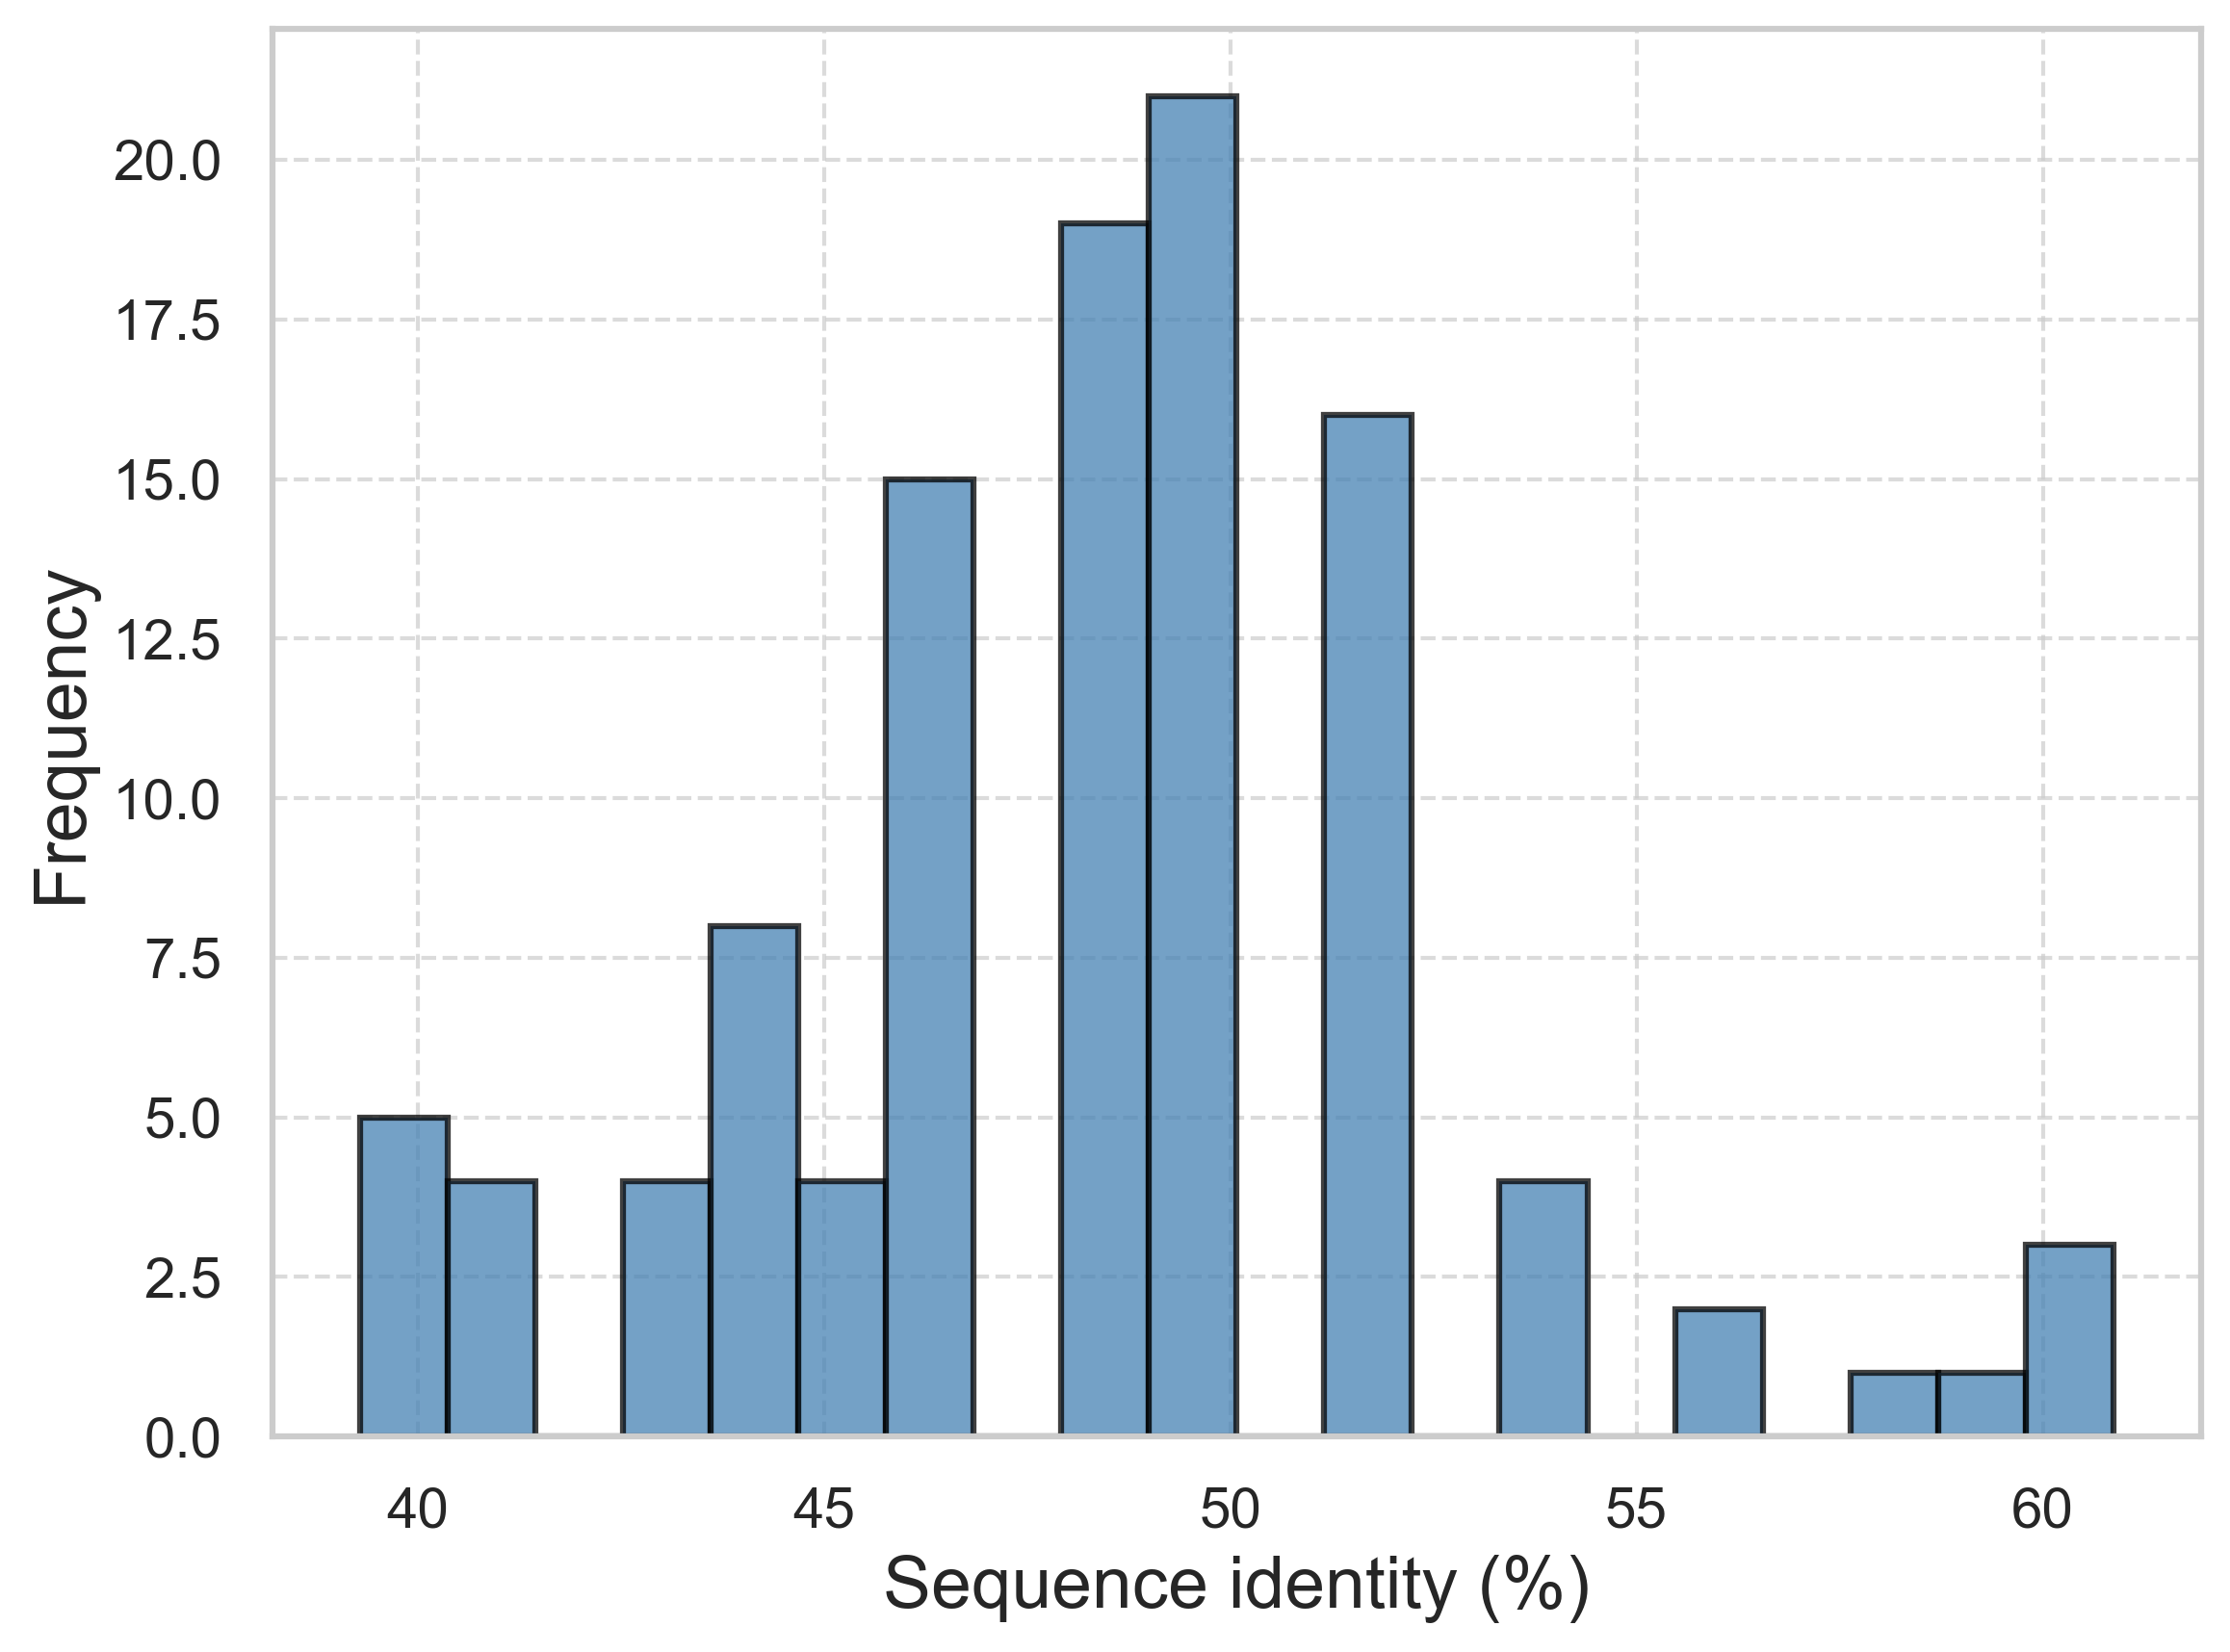

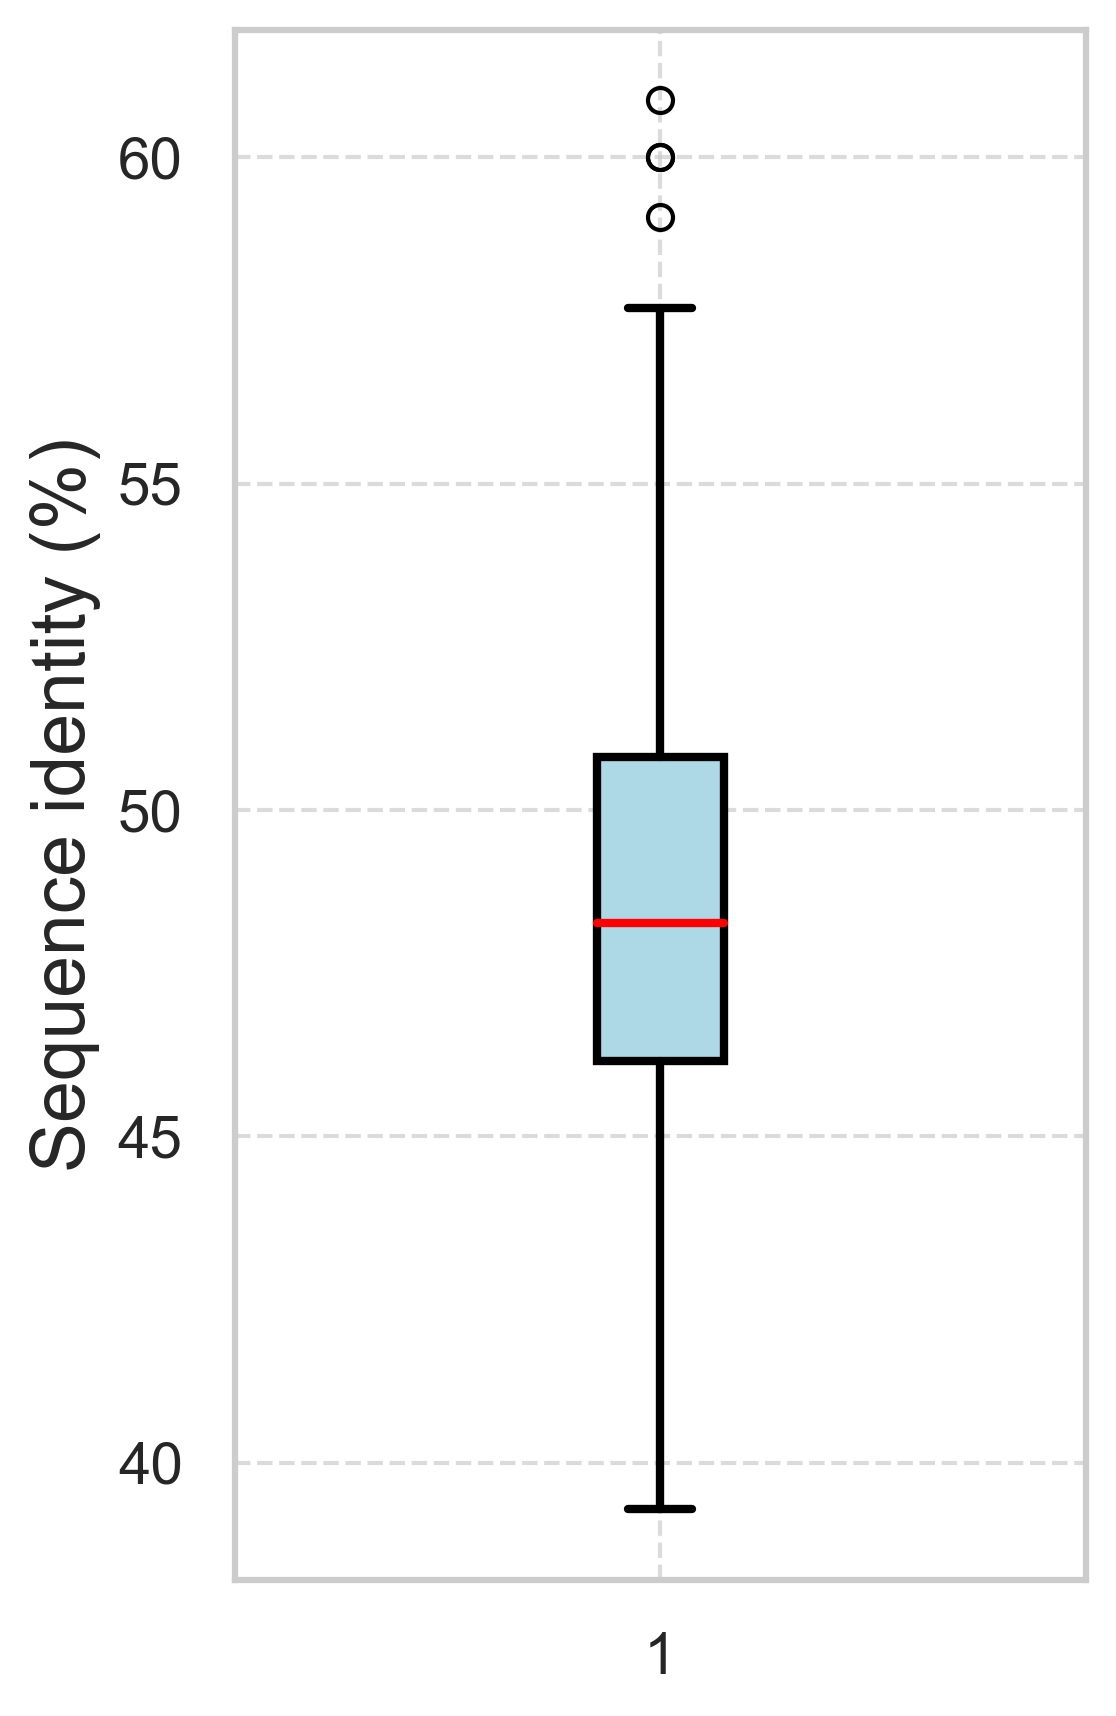

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df1 is your DataFrame containing the best_identity column
# Calculate descriptive statistics
stats = df1['best_identity'].describe()
variance = df1['best_identity'].var()
std_dev = df1['best_identity'].std()
median = df1['best_identity'].median()

print("Descriptive Statistics:")
print(stats)
print("\nAdditional Statistics:")
print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Median: {median:.2f}")

# Update global matplotlib parameters for publication quality
plt.rcParams.update({
    'font.size': 16,
    'font.family': 'sans-serif',
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.linewidth': 1.5,
    'grid.linewidth': 1.0
})

# Plot 1: Histogram of best_identity scores
fig1, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
n, bins, patches = ax1.hist(df1['best_identity'], bins=20, color='steelblue', edgecolor='black', alpha=0.75)
ax1.set_title("", fontweight='bold') #Distribution of sequence identity %
ax1.set_xlabel("Sequence identity (%)")
ax1.set_ylabel("Frequency")
ax1.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: Boxplot of best_identity scores
fig2, ax2 = plt.subplots(figsize=(4, 6), dpi=300)
bp = ax2.boxplot(df1['best_identity'],
                 vert=True,
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='black', linewidth=2),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='black', linewidth=2),
                 capprops=dict(color='black', linewidth=2))
ax2.set_title("", fontweight='bold') #Boxplot of sequence identity %
ax2.set_ylabel("Sequence identity (%)")
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
